# Test 5: Internal Event Detection and Reporting

## Overview
The implementation provides a mechanism for components to **report events that occur within their internal micro-stepping**, allowing the hybrid algorithm to accurately detect and localize events that would otherwise be missed between communication points.

## Key Features
### 1. Internal Event Hints
Components can report precise timing information about events detected during internal stepping.
- `event_name`: Name of the detected event
- `t_before`: Latest micro-step time *before* the event
- `t_after`: Earliest micro-step time *after* the event
- `indicator_before/after`: Values of the event indicator function before and after the event

### 2. Component Side Reporting
- `CoSimComponent` class includes methods for reporting an internal event
- Method `report_internal_event` is called within `_do_step_internal` when internal zero crossing is detected
- Stores the hints in `self.internal_event_hints` list for later retrieval
- Retrieved via `get_internal_event_hints()` method

### 3. Hybrid Algorithm Integration
The hybrid algorithm uses the internal hints in two phases:

**Phase 1: Event Detection**
- In `_detect_crossings`, it collects all internal hints after a trial step
- Filters hints to keep only those strictly within the current interval

**Pahse 2: Event Localization**
- In `_locate_event_time`, it uses the earliest hint to narrow the bisection interval
- This allows a reduction of the bisection iterations needed to find the event time
- Ensures accurate event localization even when events occur between communication points

### 4. State Rollback on Restore
- When restoring component state during bisection, the internal event hints are cleared
- Prevents stale hints from affecting subsequent event detection

In [1]:
import sys
from typing import Any, Dict, List, Optional
from pathlib import Path

import numpy as np

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))

from SysSimX.core.base import CoSimComponent
from SysSimX.core.port import PortSpec, PortType
from SysSimX.core.events import Event

from SysSimX.system.connection import EventConnection
from SysSimX.system.system import System

import docs.plot_setup as plot_setup
plt = plot_setup.set_professional_style()

----------------------

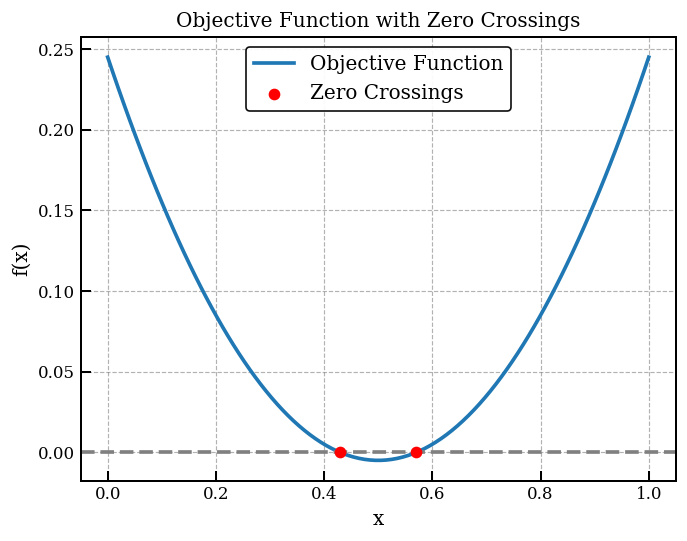

Zero Crossings at: [0.42928932188134716, 0.5707106781186528]


In [67]:
func = lambda x: (x - 0.5)**2 - 0.005

x_vals = np.linspace(0, 1, 100)
y_vals = func(x_vals)

# Get zero crossing points
from scipy.optimize import brentq
zero_crossings = []
for i in range(len(x_vals)-1):
    if y_vals[i] * y_vals[i+1] < 0:
        root = brentq(func, x_vals[i], x_vals[i+1])
        zero_crossings.append(root)

plt.plot(x_vals, y_vals, label='Objective Function')
plt.scatter(zero_crossings, [0]*len(zero_crossings), color='red', zorder=5, label='Zero Crossings')
plt.title('Objective Function with Zero Crossings')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.axhline(y=0, color='gray', linestyle='--')
plt.grid(True)
plt.show()

print("Zero Crossings at:", zero_crossings)

In [68]:
T1 = 0.45
T2 = 0.55

class HybridSource(CoSimComponent):
    def __init__(self, name: str):
        super().__init__(name, group='Sources')
        self.dt_internal = 0.01
        self.x = 0.0
        self.x_prev = 0.0
        
    def _initialize_component(self, t0: float) -> None:
        self.output_specs.update({"x": PortSpec(name="x", type=PortType.REAL, direction="out")})
        self._initialize_ports_from_specs()
        self.x = (self.t - T1) * (self.t - T2)
        self.x_prev = self.x
        
    def _do_step_internal(self, t: float, dt: float) -> None:
        self.internal_event_hints.clear()
        
        if dt < self.dt_internal - 1e-12:
            effective_dt = dt
        else:
            effective_dt = self.dt_internal
            
        t_current = t
        t_end = t + dt
        
        while t_current < t_end - 1e-12:
            step_size = min(effective_dt, t_end - t_current)
            
            self.x_prev = self.x
            t_prev = t_current
            
            t_current += step_size
            self.t = t_current
            self.x = (self.t - T1) * (self.t - T2)
            
            self._update_output_states(t=self.t)
            self._record_outputs(t=self.t)
            
            # Check for zero-crossing event
            if self.x_prev * self.x < 0:
                self.report_internal_event(
                    event_name="zero_crossing",
                    t_before=t_prev, #self.t - self.dt_internal,
                    t_after=t_current,
                    indicator_before=self.x_prev,
                    indicator_after=self.x
                )
                
    def _update_output_states(self, t: Optional[float]=None, event_names: Optional[List[str]]=[]) -> None:
        self.outputs["x"].set(self.x, t=t)
        
    def set_state(self, state: Dict[str, Any], t: float) -> None:
        if "x" in state: 
            self.x = state["x"]
        if "x_prev" in state:
            self.x_prev = state["x_prev"]
        self.t = t
            
    def get_state(self) -> Dict[str, Any]:
        return {"x": self.x, "x_prev": self.x_prev}
    
    def snapshot_state(self):
        return {"t": self.t, "x": self.x, "x_prev": self.x_prev}

    def restore_state(self, snapshot, t: Optional[float] = None) -> None:
        self.t = snapshot["t"]
        self.x = snapshot["x"]
        self.x_prev = snapshot.get("x_prev", self.x)
        # Clear internal hints on restore - they're no longer valid
        self.internal_event_hints.clear()
    
    def reset(self) -> None:
        super().reset()
        self.x = 0.0
        self.x_prev = 0.0

In [69]:
class HybridListener(CoSimComponent):
    def __init__(self, name: str, x0: float = 0.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group="Listener")
        self.x0 = x0; self.v = v; self.t0 = t0
        
    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0
        self.output_specs.update({"x": PortSpec(name="x", type=PortType.REAL, direction="out")})
        self.input_specs.update({"v_invert": PortSpec(name="v_invert", type=PortType.EVENT, direction="in")})  
        self._initialize_ports_from_specs()
        
    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)
        
    def _update_output_states(self, t: Optional[float]=None, event_names: Optional[List[str]]=[]) -> None:
        self.outputs["x"].set(self.x, t=t)
        
    def set_state(self, state: Dict[str, Any], t: float) -> None:
        if "x" in state:
            self.x = state["x"]
            
    def get_state(self) -> Dict[str, Any]:
        return {"x": self.x}
    
    def _handle_events_internal(self, event_names, t):
        if 'zero_crossing' in event_names:
            self.t0 = t
            self.x0 = self.x
            self.v = -self.v
            print(f"{self.name} handled event at t={t:.4f}: v inverted from { -self.v } to { self.v }")
    
    def reset(self) -> None:
        super().reset()

In [70]:
# 1) Create components
src_comp = HybridSource(name="Source")
listener_comp = HybridListener(name="Listener", x0=0.0,  v=0.25)

# 2) Define event indicator functions
def event_indicator_function(comp: HybridSource) -> float:
    return comp.x

# 3) Create events
event = Event(name="zero_crossing", source=src_comp.name, direction=0)

# 4) Initialize event source components
src_comp.initialize(t0=0.0)

# 5) Add event indicators to source components
src_comp.add_event_indicator(name=event.name,
                             func=event_indicator_function,
                             direction=event.direction)

# 6) Initialize listener component and subscribe to events
listener_comp.initialize(t0=0.0)
listener_comp.subscribe_event(event=event)

# 7) Create system
system = System(name="Hybrid System - Event Handling")

# 8) Add components to system
system.add_component(src_comp)
system.add_component(listener_comp)

# 9) Create and add event connections to the system
connection = EventConnection(src_comp=src_comp.name,
                             src_port=src_comp.output_specs['zero_crossing'].name,
                             dst_comp=listener_comp.name,
                             dst_port=listener_comp.input_specs['v_invert'].name)
system.add_event_connection(connection)

# 10) Initialize and run the system
system.initialize(t0=0.0)

# 11) Component classification
print("\nComponent Classification:")
for classification, components in system.classify_components().items():
    print(f" - {classification}: {[component.name for component in components]}")
print(f"\nUsing Algorithm: {system.algorithm.name}\n")


Component Classification:
 - event_sources: ['Source']
 - event_listeners: ['Listener']
 - continuous_only: []

Using Algorithm: Hybrid-Algorithm



In [71]:
print("Zero Crossings at:", zero_crossings)

Zero Crossings at: [0.42928932188134716, 0.5707106781186528]


In [72]:
# 12) Run the simulation
print("Starting hybrid co-simulation...\n")
system.algorithm.verbose = True
system.run(t0=0.0, tf=1.0, dt = 0.2)

Starting hybrid co-simulation...

  Internal hint from Source: zero_crossing in [0.44000000, 0.45000000]
  Internal hint from Source: zero_crossing in [0.54000000, 0.55000000]

Events detected in interval [0.40000000, 0.60000000]
Crossings: [('Source', 'zero_crossing')]
Internal hints: [('Source', ['zero_crossing', 'zero_crossing'])]
  Using internal hint to narrow interval: [0.40000000, 0.60000000] -> [0.44000000, 0.45000000]
Located at t=(0.45000000, 0)
Already handled events: set()

Handling events at (0.45000000, 0): [('Source', 'zero_crossing')]

Events grouped by component for handling: {'Listener': ['zero_crossing']}

Dispatching event 'zero_crossing' from 'Source' to targets: ['Listener']
Listener handled event at t=0.4500: v inverted from 0.25 to -0.25

  Internal hint from Source: zero_crossing in [0.45000000, 0.46000000]
  Internal hint from Source: zero_crossing in [0.55000000, 0.56000000]

Events detected in interval [0.45000000, 0.60000000]
Crossings: [('Source', 'zero_cr

In [73]:
time_src_1, data_src_1 = src_comp.get_history_arrays()
x_src_1 = data_src_1['x']

time_listener, data_listener = listener_comp.get_history_arrays()
x_listener = data_listener['x']

event_history = system.history.get_all_event_histories()
trigger_times = event_history.get((src_comp.name, 'zero_crossing'), [])

trigger_time_1 = trigger_times[0].t
trigger_time_2 = trigger_times[1].t

In [74]:
for event_key, events in event_history.items():
    print(f"\nEvents for {event_key}:")
    for event in events:
        print(f" - Event at t={event.t}")


Events for ('Source', 'zero_crossing'):
 - Event at t=0.44999999940395363
 - Event at t=0.5499999996039537


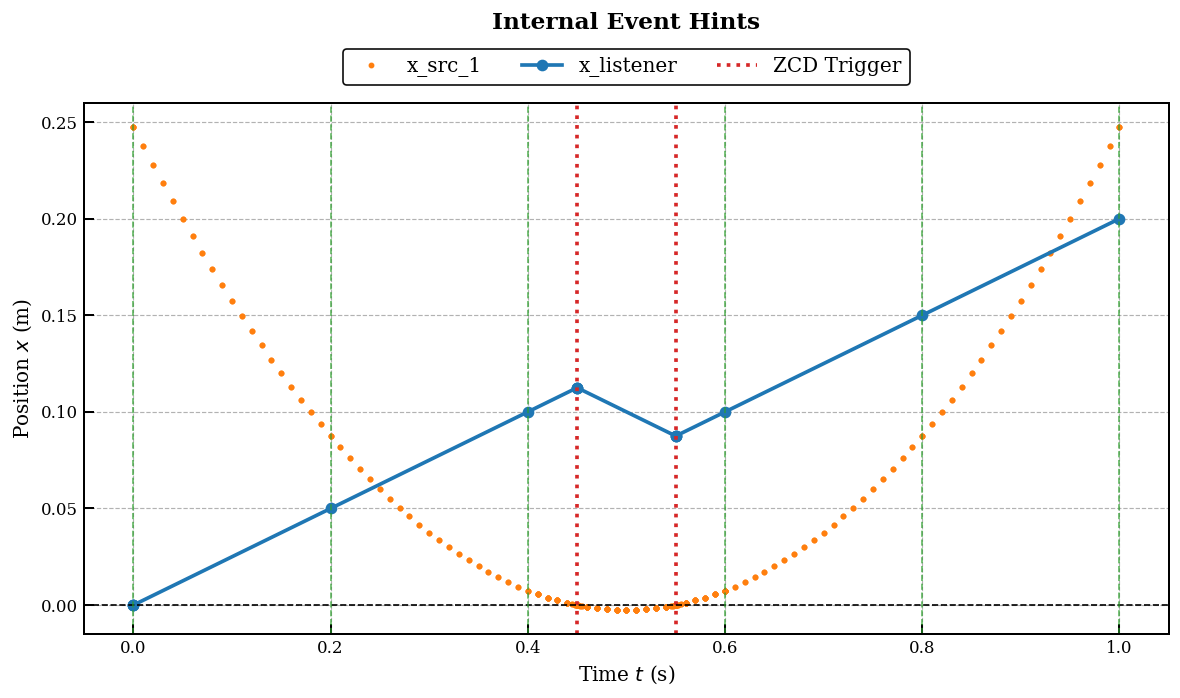

In [75]:
plt.figure(figsize=(10, 6))
plt.plot(time_src_1, x_src_1, label='x_src_1', color='tab:orange', linestyle='None', marker='.', markersize=5)
plt.plot(time_listener, x_listener, label='x_listener', color='tab:blue', marker='o', linestyle='-')
plt.axvline(trigger_time_1, color='tab:red', linestyle=':', label='ZCD Trigger')
plt.axvline(trigger_time_2, color='tab:red', linestyle=':')
plt.axhline(0, color='black', linestyle='--', linewidth=1)

communication_points = np.arange(0, 1.01, 0.2)
for cp in communication_points:
    plt.axvline(cp, color='tab:green', linestyle='--', linewidth=1, alpha=0.75)

plt.title('Internal Event Hints', fontsize=14, fontweight='bold', y= 1.12)
plt.xlabel('Time $t$ (s)')
plt.ylabel('Position $x$ (m)')
plt.grid()
plt.legend(loc='upper center', ncol=5, bbox_to_anchor=(0.5, 1.12))
plt.tight_layout()
plt.savefig('../figures/Hybrid/test_5_internal_event_hints_1.svg')
plt.show()

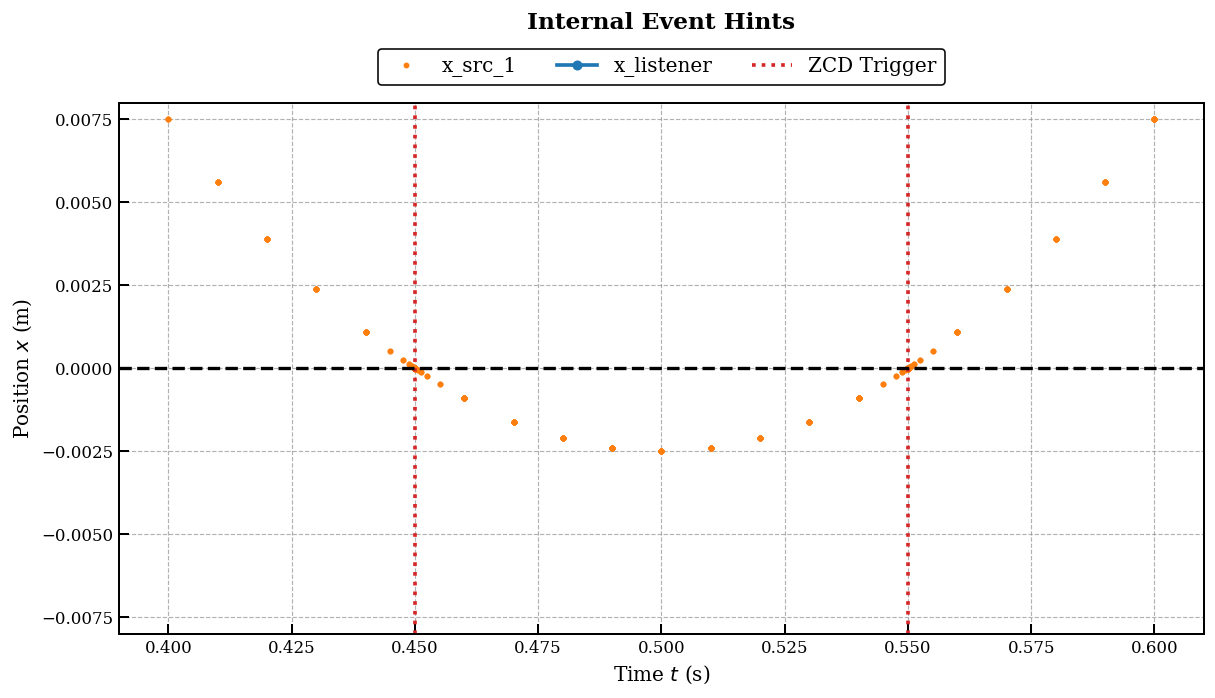

In [76]:
plt.figure(figsize=(10, 6))
plt.plot(time_src_1, x_src_1, label='x_src_1', color='tab:orange', linestyle='None', marker='.', markersize=5)
plt.plot(time_listener, x_listener, label='x_listener', color='tab:blue', linestyle='-', marker='o', markersize=5)
plt.axvline(trigger_time_1, color='tab:red', linestyle=':', label='ZCD Trigger')
plt.axvline(trigger_time_2, color='tab:red', linestyle=':')
plt.axhline(0, color='black', linestyle='--', linewidth=2)
plt.title('Internal Event Hints', fontsize=14, fontweight='bold', y= 1.12)
plt.xlabel('Time $t$ (s)')
plt.ylabel('Position $x$ (m)')
plt.grid()
plt.legend(loc='upper center', ncol=5, bbox_to_anchor=(0.5, 1.12))
plt.tight_layout()
plt.xlim(0.39, 0.61)
plt.ylim(-0.008, 0.008)
plt.yticks(np.arange(-0.0075, 0.008, 0.0025))
plt.xticks(np.arange(0.4, 0.6025, 0.025))
plt.savefig('../figures/Hybrid/test_5_internal_event_hints_2.svg')
plt.show()